# EC1036 - Inteligência Computacional
## Tópico: Introdução a redes neurais artificiais

As Redes Neurais Artificiais são modelos computacionais inspirados no sistema nervoso central de animais. Elas podem ser visualizadas como **grafos de cálculo**, onde operações matemáticas e variáveis fluem através de conexões. 

Estruturas complexas de Deep Learning são construídas através da composição de funções mais simples, muitas vezes processadas de forma paralela em GPUs usando bibliotecas como **TensorFlow** ou **PyTorch**.

## 1. O Perceptron e o Problema do XOR

<div align="center">
    <img src="../imagens/perceptron.png" alt="exemplo ann" width="500">
<div>

O **Perceptron** é a forma mais simples de rede neural artificial. Ele é composto por um único neurônio artificial que recebe entradas, associa pesos a cada uma delas, soma tudo e aplica uma função de ativação para produzir a saída.

Matematicamente, o Perceptron pode ser representado por:

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

ou, de forma vetorial:

$$
z = \mathbf{w}^T \mathbf{x} + b
$$

onde:

- $x_i$ são as entradas
- $w_i$ são os pesos associados a cada entrada
- $b$ é o viés (*bias*)
- $z$ é a combinação linear das entradas

Em seguida, aplica-se uma função de ativação de passo (*step function*):

$$
\hat{y} = f(z) =
\begin{cases}
1, & \text{se } z \ge 0 \\
0, & \text{se } z < 0
\end{cases}
$$

A saída $\hat{y}$ indica a classe prevista pelo modelo.

**A Limitação:** o Perceptron original é um classificador **linear**. Isso significa que ele só consegue separar corretamente dados que podem ser divididos por uma reta, plano ou hiperplano. Por esse motivo, ele é incapaz de resolver problemas **não linearmente separáveis**, como a função lógica do **OU Exclusivo (XOR)**.

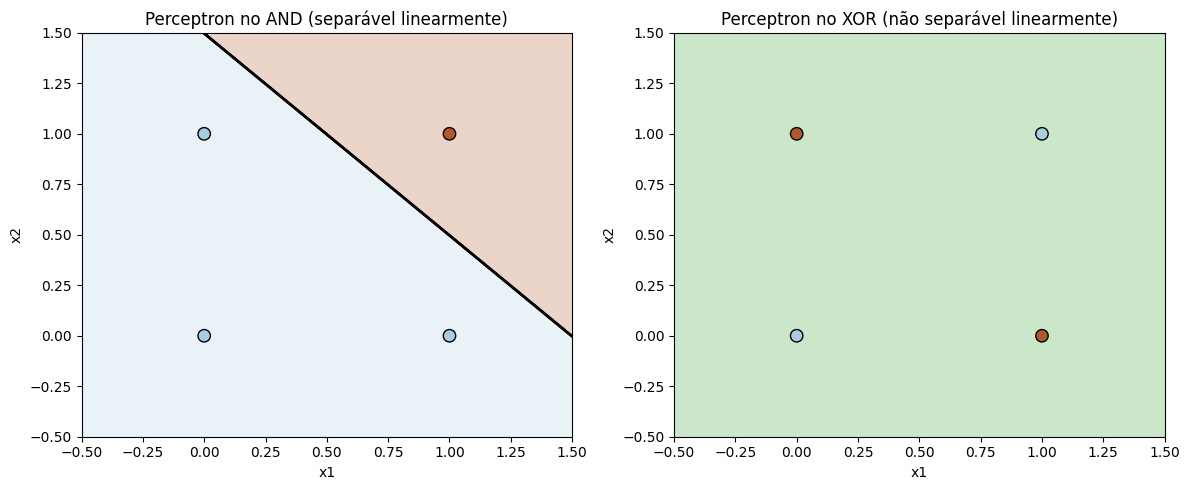

In [26]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

# Desenha a fronteira de decisão do modelo em um gráfico
def plot_decision_boundary(ax, clf, X_data, y_data, title):
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Faz a predição para cada ponto da grade
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Plota a região de decisão e os pontos originais
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.Paired)
    ax.contour(xx, yy, Z, colors="k", linewidths=1)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=plt.cm.Paired, edgecolor="k", s=80)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

#problema AND
X_and = np.array([[0, 0], 
                  [0, 1], 
                  [1, 0], 
                  [1, 1]])
y_and = np.array([0, 0, 0, 1])

#problema XOR
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Treina os perceptrons
and_clf = Perceptron(random_state=42, max_iter=1000, tol=1e-3)
and_clf.fit(X_and, y_and)

xor_clf = Perceptron(random_state=42, max_iter=1000, tol=1e-3)
xor_clf.fit(X_xor, y_xor)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_decision_boundary(
    axes[0], and_clf, X_and, y_and,
    "Perceptron no AND (separável linearmente)"
)

plot_decision_boundary(
    axes[1], xor_clf, X_xor, y_xor,
    "Perceptron no XOR (não separável linearmente)"
)

plt.tight_layout()
plt.show()

## 2. Multilayer Perceptron (MLP) e Forward Pass


Para superar a limitação do Perceptron simples, combinamos vários neurônios em camadas, formando o **Multilayer Perceptron (MLP)**. Essa arquitetura permite aprender **fronteiras de decisão não lineares** e modelar padrões mais complexos.

Em um MLP, os neurônios são organizados em três tipos de camadas:

1. **Camada de Entrada (Input Layer):** recebe as variáveis do problema.  
2. **Camadas Ocultas (Hidden Layers):** extraem e transformam características intermediárias.  
3. **Camada de Saída (Output Layer):** gera a previsão final.

O fluxo de informação da entrada até a saída é chamado de **Feedforward** (ou **Forward Pass**). Em cada camada, calcula-se uma combinação linear das entradas com os pesos e o viés, seguida de uma função de ativação não linear:

$
\mathbf{z}^{(l)} = \mathbf{W}^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}, \qquad
\mathbf{a}^{(l)} = g\!\left(\mathbf{z}^{(l)}\right)
$

Essa não linearidade é o que torna o MLP capaz de representar relações complexas nos dados.


<div align="center">
    <img src="../imagens/exemplo_ann.png" alt="exemplo ann" width="500">
<div>

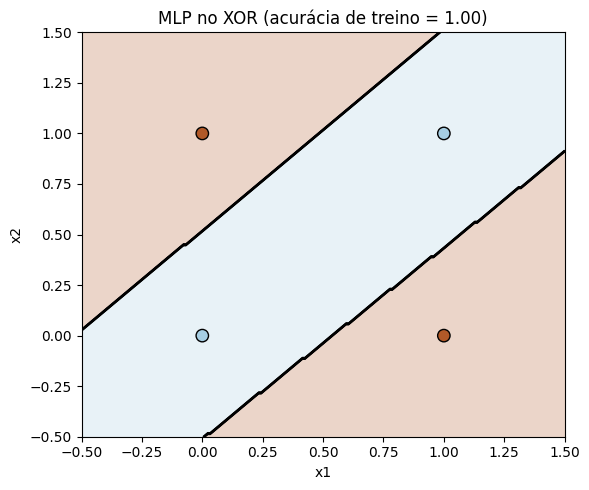

Previsões do MLP para XOR: [0 1 1 0]


In [5]:
from sklearn.neural_network import MLPClassifier

# Exemplo de classificação com MLP no problema XOR
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# MLP com uma camada oculta de 4 neurônios e ativação não linear
mlp_xor = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation="tanh",
    solver="lbfgs",
    random_state=42,
    max_iter=5000
)
mlp_xor.fit(X_xor, y_xor)

y_pred_xor = mlp_xor.predict(X_xor)
acc_xor = (y_pred_xor == y_xor).mean()

fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(
    ax, mlp_xor, X_xor, y_xor,
    f"MLP no XOR (acurácia de treino = {acc_xor:.2f})"
)
plt.tight_layout()
plt.show()

print("Previsões do MLP para XOR:", y_pred_xor)

## 3. Funções de Ativação:


A função de ativação é responsável por introduzir a não-linearidade na rede neural, permitindo que ela aprenda mapeamentos complexos (sem elas, não importaria a quantidade de camadas, a rede se comportaria apenas como um modelo de regressão linear). 

Abaixo estão as principais funções utilizadas, desde as mais clássicas até as recomendadas no estado-da-arte (Deep Learning):

1. Função Degrau (Step Function):

    Foi a primeira função utilizada no Perceptron clássico. Ela retorna 1 se o valor da entrada (soma ponderada) for maior ou igual a zero, e 0 caso contrário. Não é usada em redes modernas com *Backpropagation* pois sua derivada é zero em quase toda parte, impossibilitando o aprendizado pelo gradiente.
$$f(z) = \begin{cases} 1 & \text{se } z \ge 0 \\ 0 & \text{se } z < 0 \end{cases}$$

<div align="center">
    <img src="../imagens/fun_step.png" alt="" width="500">
</div>

---

2. Logística (Sigmoide):

    Historicamente muito popular, ela "esmaga" os valores de entrada para um intervalo entre 0 e 1, sendo útil para interpretar saídas como probabilidades. Hoje em dia é mais usada apenas na camada de saída para classificação binária, pois sofre com o problema do *Vanishing Gradient* (gradientes desaparecem nas extremidades).
$$f(z) = \frac{1}{1 + e^{-z}}$$

<div align="center">
    <img src="../imagens/sigmoid.png" alt="" width="500">
</div>

---

3. Tangente Hiperbólica (Tanh):

    Semelhante à Sigmoide, mas retorna valores no intervalo entre -1 e 1. A vantagem é que sua saída é centrada em zero, o que geralmente ajuda a rede a convergir mais rápido que a sigmoide clássica. No entanto, ainda sofre com a saturação dos gradientes em redes profundas.
    $$f(z) = \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

<div align="center">
    <img src="../imagens/tanh.png" alt="" width="500">
</div>

---

4. ReLU (Rectified Linear Unit):

    É a função de ativação mais popular atualmente nas camadas ocultas. É extremamente rápida para calcular e não satura para valores positivos, o que ajuda muito a mitigar o desaparecimento do gradiente. O problema da ReLU é o *Dying ReLU* (neurônios mortos): se os pesos forem atualizados de forma que a entrada da função seja sempre negativa, o neurônio passará a emitir apenas 0 e nunca mais aprenderá.
    $$f(z) = \max(0, z)$$

<div align="center">
    <img src="../imagens/relu.png" alt="" width="500">
</div>

---
5. Leaky ReLU:

    Uma variação criada para combater o problema dos "neurônios mortos". Em vez de retornar zero para valores negativos, ela retorna um valor pequeno com uma leve inclinação (o "vazamento"), controlado por um parâmetro $\alpha$ (geralmente algo como 0.01).
    $$f(z) = \max(\alpha z, z)$$

<div align="center">
    <img src="../imagens/leaky_relu.png" alt="" width="500">
</div>

---
6. ELU (Exponential Linear Unit):

    Considerada uma evolução para combater o *Dying ReLU*. Ela suaviza a curva para valores negativos usando uma função exponencial, o que garante que a média das saídas fique mais próxima de zero, acelerando a convergência.
    $$f(z) = \begin{cases} z & \text{se } z \ge 0 \\ \alpha(e^z - 1) & \text{se } z < 0 \end{cases}$$

<div align="center">
    <img src="../imagens/elu.png" alt="" width="500">
</div>

---
7. Softmax (Para a Camada de Saída):

    Exclusiva para a camada de saída em problemas de **Classificação Multiclasse**. Ela recebe um vetor de valores $v$ e os transforma em uma distribuição de probabilidades, onde todos os valores resultantes ficam entre 0 e 1 e a soma de todos eles é exatamente 1. O índice com o maior valor é a classe prevista.
    $$f(z_k) = \frac{e^{z_k}}{\sum_{i=1}^{n} e^{z_i}}$$

<div align="center">
    <img src="../imagens/softmax1.png" alt="" width="500">
</div>

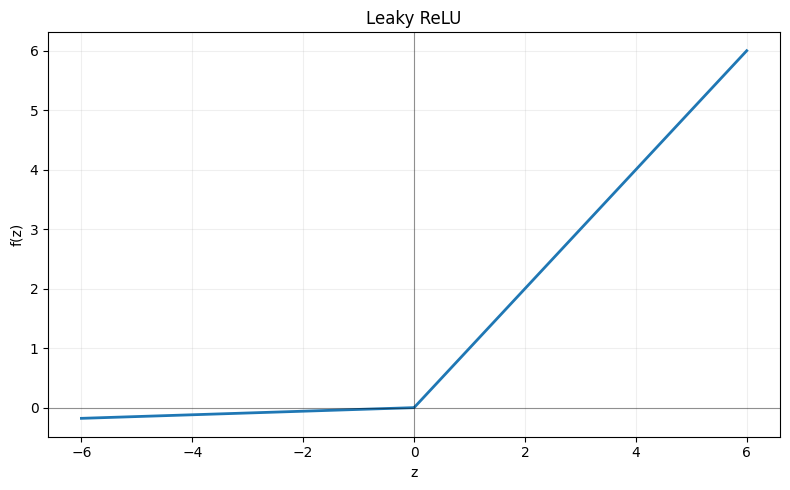

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 600)

def step(z):
    return np.where(z >= 0, 1, 0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.03):
    return np.where(z >= 0, z, alpha * z)

def elu(z, alpha=1.0):
    return np.where(z >= 0, z, alpha * (np.exp(z) - 1))

def softmax_demo(z):
    logits = np.vstack([z, np.zeros_like(z), np.zeros_like(z)]).T
    exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exps / np.sum(exps, axis=1, keepdims=True)
    return probs[:, 0]

activation_functions = {
    "step": ("Step", step),
    "sigmoid": ("Sigmoid", sigmoid),
    "tanh": ("Tanh", tanh),
    "relu": ("ReLU", relu),
    "leaky_relu": ("Leaky ReLU", leaky_relu),
    "elu": ("ELU", elu),
    "softmax": ("Softmax", softmax_demo),
}

funcao_escolhida = "leaky_relu"  # troque para: step, tanh, relu, leaky_relu, elu, softmax

if funcao_escolhida not in activation_functions:
    raise ValueError(f"Função desconhecida: {funcao_escolhida}")

nome, func = activation_functions[funcao_escolhida]

plt.figure(figsize=(8, 5))
plt.plot(x, func(x), linewidth=2)
plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.4)
plt.title(nome)
plt.xlabel("z")
plt.ylabel("f(z)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. O Treinamento: Backpropagation e Gradiente Descendente

Treinar uma rede neural é como tentar descer uma montanha de olhos vendados. Você não sabe onde está o fundo do vale (o menor erro possível), mas consegue sentir a inclinação do chão debaixo dos seus pés. O objetivo do treinamento é dar passos na direção em que a descida é mais íngreme até chegar ao ponto mais baixo.

Esse processo pode ser dividido em etapas iterativas:

### Passo 1: O *Forward Pass* e a Função de Custo (Cost Function)
Primeiro, os dados de entrada passam pela rede (multiplicados pelos pesos e ativados pelas funções), gerando uma previsão final. Essa previsão é então comparada com o valor real esperado (o rótulo).

A medida de "o quão errada" a nossa previsão está é dada pela **Função de Custo (Loss Function)**. Imagine essa função como uma superfície 3D cheia de vales e montanhas. O nosso objetivo é encontrar o ponto mais baixo dessa superfície.

<div align="center">
    <img src="../imagens/cost_function_exem.jpg" alt="" width="500">
</div>

Para diferentes problemas, usamos diferentes funções de custo:
* **Erro Quadrático Médio (MSE - Mean Squared Error):** Usado em problemas de **Regressão** (prever um valor contínuo).
    $$L = \frac{1}{2}(t - y)^2$$
    *(Onde $t$ é o valor real esperado e $y$ é a saída prevista pela rede).*

* **Entropia Cruzada (Cross-Entropy):** Usada em problemas de **Classificação** (prever categorias).
    $$L = -\sum t_i \log y_i$$

---

### Passo 2: *Backpropagation* (Distribuindo a Culpa)
Depois de calcularmos o erro, precisamos saber: *quanto cada peso ($W$) da rede contribuiu para esse erro final?*

É aqui que entra o **Backpropagation** (Retropropagação do Erro). Ele usa um conceito do cálculo chamado **Regra da Cadeia (Chain Rule)**. O algoritmo calcula a derivada do erro em relação a cada peso, começando pela camada de saída e voltando camada por camada até a entrada. 



Basicamente, o Backpropagation nos dá o **Gradiente** (a inclinação da nossa montanha). Ele nos diz: "Se aumentarmos um pouco este peso específico, o erro vai subir ou descer?".

---

### Passo 3: O Gradiente Descendente (Gradient Descent)
Com o gradiente (a inclinação) em mãos, sabemos para qual direção devemos "dar o passo" para reduzir o erro. O algoritmo do **Gradiente Descendente** atualiza os pesos movendo-os na direção *oposta* ao gradiente.

A fórmula de atualização de um peso $W$ é:

$$W_{novo} = W_{atual} - \eta \frac{\partial L}{\partial W}$$

Onde:
* $W_{novo}$ e $W_{atual}$ são os pesos da conexão.
* $\frac{\partial L}{\partial W}$ é o gradiente (a derivada do Custo $L$ em relação ao peso $W$).
* $\eta$ é a **Taxa de Aprendizado (Learning Rate)**. 


<div align="center">
    <img src="../imagens/gradiente_descendente.png" alt="" width="500">
</div>


#### A importância da Taxa de Aprendizado ($\eta$)
A Taxa de Aprendizado é o "tamanho do passo" que damos montanha abaixo:
* Se $\eta$ for **muito pequeno**, a rede demorará uma eternidade para aprender e pode ficar presa em buracos rasos (mínimos locais).
* Se $\eta$ for **muito grande**, a rede dará passos tão grandes que pulará o fundo do vale e o erro começará a divergir (aumentar descontroladamente).
* O ideal é começar com uma taxa alta e ir reduzindo ao longo do tempo.
---

<div align="center">
    <img src="../imagens/backpropagation.png" alt="" width="900">
</div>


### Estratégias de Lote (Mini-batching)

Na prática, não calculamos o erro para apenas um exemplo por vez, nem para toda a base de dados de uma só vez. Dividimos os dados em lotes e escolhemos entre diferentes estratégias de atualização:

1. **Stochastic Gradient Descent (SGD):** Tamanho do lote = 1. Atualiza os pesos a cada exemplo individual. A descida é extremamente ruidosa e caótica, levando a flutuações grandes no erro durante o treinamento.

2. **Batch Gradient Descent:** Tamanho do lote = dataset inteiro. Calcula o gradiente usando todos os dados antes de atualizar os pesos. A curva de descida é suave e previsível, mas é computacionalmente inviável para bases de dados grandes, pois requer cálculos massivos antes de cada atualização.

3. **Mini-batch Gradient Descent:** O meio-termo ideal na prática. Divide os dados em pequenos pacotes (tipicamente 32, 64 ou 128 instâncias). Oferece a melhor combinação: acelera o treinamento permitindo paralelização em GPUs usando operações vetorizadas, mantém a descida relativamente estável, e reduz a variância em relação ao SGD.

A escolha do tamanho do lote é um hiperparâmetro importante que impacta diretamente a velocidade e a qualidade do treinamento.

### Otimizadores: Acelerando a Descida
No Gradiente Descendente padrão (SGD), atualizamos os pesos multiplicando o gradiente pela taxa de aprendizado. No entanto, na prática, a "montanha" da Função de Custo ($L$) é cheia de vales sinuosos, buracos e platôs. Usar apenas o SGD pode ser muito lento ou fazer a rede ficar presa em buracos rasos (mínimos locais).

Para resolver isso, usamos os **Otimizadores**. Eles são algoritmos que modificam a forma como a atualização dos pesos é calculada, adaptando o tamanho do "passo" para acelerar a descida. 

Para as equações abaixo, considere:
* $W_t$: O peso no momento atual.
* $g_t$: O gradiente no momento atual, ou seja, $\frac{\partial L}{\partial W}$.
* $\eta$: A taxa de aprendizado.

#### 1. SGD (Stochastic Gradient Descent)
É a versão clássica. Ele apenas dá um passo na direção oposta ao gradiente.
$$W_{t+1} = W_t - \eta g_t$$
* **O problema:** Se o vale for muito estreito, ele fica "quicando" de um lado para o outro da parede do vale e demora a descer até o fundo.

#### 2. Momentum
Imagine soltar uma bola de boliche no topo de uma ladeira. À medida que ela desce, ganha embalo (momento). O otimizador *Momentum* faz exatamente isso: ele lembra da direção dos passos anteriores e adiciona uma fração desse histórico ao passo atual. Isso ajuda a passar direto por platôs e suaviza os "quiques" do SGD.
$$v_t = \gamma v_{t-1} + \eta g_t$$
$$W_{t+1} = W_t - v_t$$
* Onde $v_t$ é a velocidade (o acúmulo dos gradientes passados) e $\gamma$ é o fator de momento (geralmente $0.9$).

#### 3. RMSprop (Root Mean Square Propagation)
O RMSprop funciona como um "freio ABS". Se um peso tem gradientes muito grandes (uma ladeira muito íngreme), ele dá passos menores para não perder o controle; se tem gradientes pequenos, ele dá passos maiores. Ele faz isso dividindo a taxa de aprendizado por uma média dos gradientes recentes.
$$s_t = \beta s_{t-1} + (1-\beta) g_t^2$$
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{s_t + \epsilon}} g_t$$
* Onde $s_t$ é o acúmulo dos gradientes ao quadrado, $\beta$ é a taxa de decaimento e $\epsilon$ é um número minúsculo para evitar divisão por zero.

#### 4. Adam (Adaptive Moment Estimation)
O **Adam** é o "padrão-ouro" atual para a maioria das redes neurais. Ele basicamente **junta o melhor dos dois mundos**: o embalo do *Momentum* e o freio inteligente do *RMSprop*.

Ele calcula médias para o momento ($m_t$) e para a velocidade ($v_t$), aplica uma correção matemática para o início do treino ($\hat{m}_t$ e $\hat{v}_t$) e atualiza os pesos de forma altamente otimizada:
$$W_{t+1} = W_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

## 5. Treinando uma Rede Neural

## Utilizando sklearn

Iniciando o treinamento com Early Stopping...
Treinamento interrompido na época 29.

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.96      0.97        50
           2       0.92      1.00      0.96        47
           3       0.98      0.93      0.95        54
           4       1.00      1.00      1.00        60
           5       0.98      0.95      0.97        66
           6       0.96      0.98      0.97        53
           7       0.98      0.98      0.98        55
           8       0.95      0.93      0.94        43
           9       0.92      0.95      0.93        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



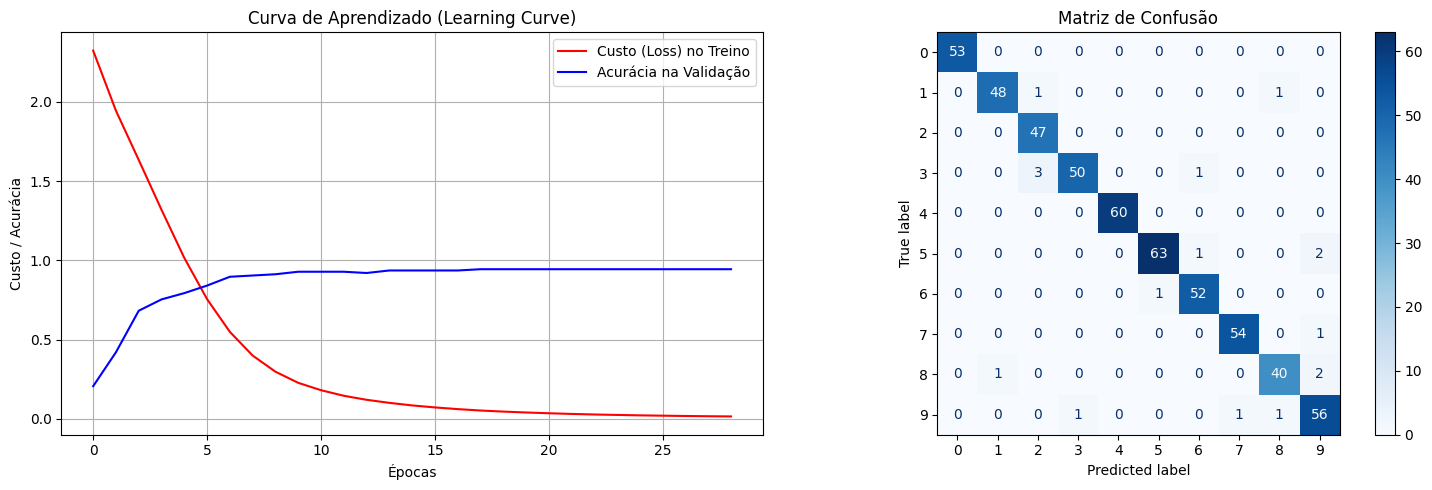

In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Carregando um dataset mais complexo (Reconhecimento de Dígitos)
# São 1797 imagens de números de 0 a 9, cada uma com 64 pixels (8x8)
digits = load_digits()
X, y = digits.data, digits.target

# Divisão dos dados (Treino e Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalonamento dos dados (Padronização)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Configurando a Rede Neural Avançada
mlp_advanced = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), # 3 camadas ocultas compactando a informação
    activation='relu',                # Função de ativação
    solver='adam',                    # Otimizador
    alpha=0.001,                      # Regularização L2 (ajuda a evitar overfitting)
    learning_rate='adaptive',         # Reduz a taxa de aprendizado se o erro não cair
    learning_rate_init=0.001,         # Taxa inicial
    max_iter=500,                     # Máximo de épocas
    early_stopping=True,              # ATIVA A PARADA ANTECIPADA
    validation_fraction=0.1,          # Reserva 10% do treino para monitorar a validação
    n_iter_no_change=10,              # Quantas épocas esperar sem melhora antes de parar
    random_state=42,
    verbose=False                     # Mude para True se quiser ver o log de cada época no console
)

# Treinando o modelo
print("Iniciando o treinamento com Early Stopping...")
mlp_advanced.fit(X_train_scaled, y_train)
print(f"Treinamento interrompido na época {mlp_advanced.n_iter_}.")

# Avaliação do modelo
y_pred = mlp_advanced.predict(X_test_scaled)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Visualizando os Resultados Gráficos
# Criando uma figura com dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Curva de Custo (Loss) e Score de Validação
# Mostra como o erro caiu e a precisão subiu ao longo das épocas
axes[0].plot(mlp_advanced.loss_curve_, label='Custo (Loss) no Treino', color='red')
if mlp_advanced.early_stopping:
    axes[0].plot(mlp_advanced.validation_scores_, label='Acurácia na Validação', color='blue')
axes[0].set_title("Curva de Aprendizado (Learning Curve)")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Custo / Acurácia")
axes[0].legend()
axes[0].grid(True)

# Gráfico 2: Matriz de Confusão
# Mostra exatamente quais números a rede mais confundiu (ex: previu 8 mas era 3)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], cmap='Blues')
axes[1].set_title("Matriz de Confusão")

plt.tight_layout()
plt.show()

### Utilizando o Tensorboard

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import TensorBoard
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import datetime
import os

# Carregando os Dados de Regressão (Valores Contínuos)
print("Carregando dataset...")
housing = fetch_california_housing()
X, y = housing.data, housing.target # 'y' agora é o preço das casas em centenas de milhares de dólares

# Divisão dos dados (Treino e Teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalonamento dos dados (Crucial para Redes Neurais)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Construindo a Rede Neural para Regressão
# A principal diferença aqui é a CAMADA DE SAÍDA
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    
    # ATENÇÃO: Para prever um valor contínuo, a camada de saída 
    # tem apenas 1 neurônio e NENHUMA função de ativação (saída linear).
    Dense(1) 
])

# Compilando o Modelo
# Em vez de 'accuracy' e 'cross_entropy', usamos métricas de erro contínuo.
# MSE (Mean Squared Error) para a perda, e MAE (Mean Absolute Error) para monitoramento.
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Configurando o TensorBoard
# Criamos uma pasta única baseada na data e hora atual para não sobrepor logs antigos
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

# O histogram_freq=1 permite que o TensorBoard visualize a distribuição dos pesos a cada época
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Treinamento com Monitoramento
print("Iniciando o treinamento. Os logs estão sendo salvos para o TensorBoard...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    validation_split=0.2, # Separa 20% do treino para validação a cada época
    callbacks=[tensorboard_callback], # Conectando o TensorBoard aqui!
    verbose=1
)

# Avaliação Final
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTreinamento concluído!")
print(f"Erro Absoluto Médio (MAE) no Teste: U$ {mae * 100000:.2f}")

# Predições no conjunto de teste e métricas adicionais
y_pred_test = model.predict(X_test_scaled).ravel()

rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
r2 = 1 - np.sum((y_test - y_pred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"RMSE no Teste: U$ {rmse * 100000:.2f}")
print(f"R² no Teste: {r2:.4f}")
print(f"MAPE no Teste: {mape:.2f}%")

Carregando dataset...
Iniciando o treinamento. Os logs estão sendo salvos para o TensorBoard...
Epoch 1/100


/home/frank/miniconda3/envs/ic_guide/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0519 - mae: 0.7037 - val_loss: 0.5215 - val_mae: 0.5061
Epoch 2/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4354 - mae: 0.4689 - val_loss: 0.4197 - val_mae: 0.4479
Epoch 3/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3768 - mae: 0.4362 - val_loss: 0.4103 - val_mae: 0.4577
Epoch 4/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3670 - mae: 0.4266 - val_loss: 0.4124 - val_mae: 0.4387
Epoch 5/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3673 - mae: 0.4195 - val_loss: 0.3968 - val_mae: 0.4414
Epoch 6/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3470 - mae: 0.4081 - val_loss: 0.3637 - val_mae: 0.4315
Epoch 7/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3274 - mae: 0.4011 - val_loss: 0.3505 - val_mae: 0.4192
Epoch 8/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3210 - mae: 0.3943 - val_loss: 0.3426 - val_mae: 0.4068
Epoch 9/100
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss:

Os valores impressos ao final do treinamento mostram como o modelo está se saindo no conjunto de teste:

- **MAE no Teste**: é o erro absoluto médio. Ele indica, em média, quanto o modelo erra em dólares ao prever o preço das casas. Quanto menor, melhor.
- **RMSE no Teste**: é a raiz do erro quadrático médio. Ele também mede o erro médio, mas penaliza mais os erros grandes. Se o RMSE fica maior que o MAE, isso costuma indicar que existem algumas previsões com erro alto.
- **R² no Teste**: mede quanto da variação dos preços o modelo consegue explicar. Valores próximos de 1 indicam bom ajuste; valores próximos de 0 indicam que o modelo explica pouco.
- **MAPE no Teste**: é o erro percentual médio. Ele mostra, em média, qual porcentagem do valor real o modelo está errando.